# Can we extract $\mathcal{H}$ using DNNs as in *Neural Network generated parametrizations of deeply virtual Compton form factors*?

The paper that we are following is: https://arxiv.org/abs/1106.2808

## (1): Import Libraries:

In [91]:
import glob
from sklearn.model_selection import train_test_split
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from iminuit import Minuit
from scipy.integrate import quad

## (2): Data Collection:

### (2.1): Collect and Load the Train/Test Data used in the Original Paper:

#### (2.1.1): BCA Data:

In [92]:
bca_1_data = pd.read_csv("data_bca_1.csv")
print(bca_1_data.columns)

Index(['bin', 'k', '-t', 'x_b', 'q_squared', 'phi', 'bca_1', 'bca_1_stat_plus',
       'bca_1_stat_minus', 'bca_1_sys_plus', 'bca_1_sys_minus'],
      dtype='object')


#### (2.1.2): BSA Data:

In [93]:
bsa_1_data = pd.read_csv('data_a_lu_i_1.csv')
print(bsa_1_data.columns)

Index(['bin', 'k', '-t', 'x_b', 'q_squared', 'phi', 'a_sin_lu_i_1',
       'a_sin_lu_i_1_stat_plus', 'a_sin_lu_i_1_stat_minus',
       'a_sin_lu_i_1_sys_plus', 'a_sin_lu_i_1_sys_minus'],
      dtype='object')


### (2.2): Can we re-make the plots with the data in the HERMES paper?

The main figure we want to remake is Figure 3 in the original paper (the DNN one). That involves plotting $A_{C}^{\cos{\phi}}$ and $A_{LU}^{\sin{\phi}}$ as they vary individually with $-t$, $x_{B}$, and $Q^{2}$.

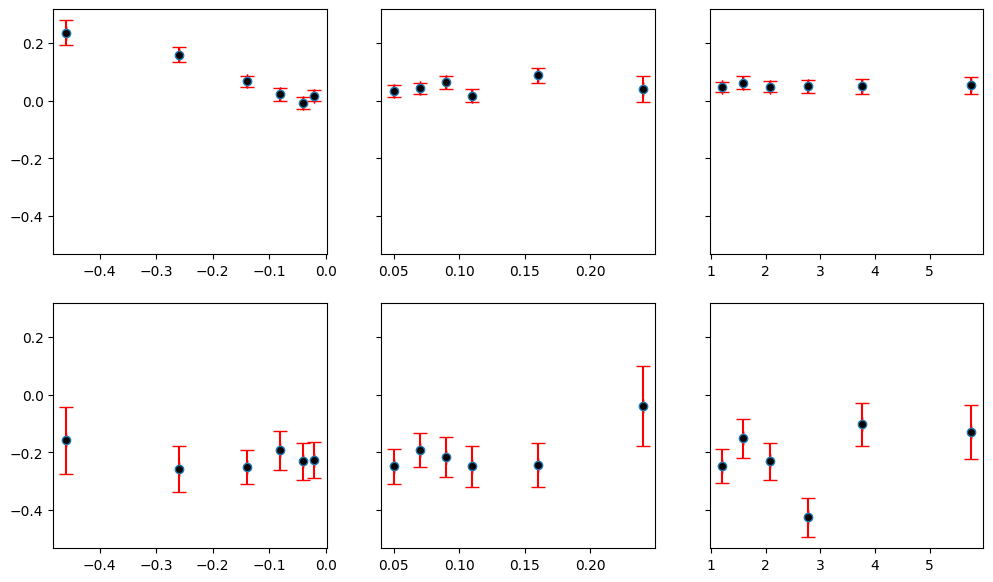

In [96]:
fig, ax = plt.subplots(2, 3, sharey = True, figsize = (12, 7))

ax[0][0].errorbar(
    bca_1_data["-t"].iloc[:6],
    bca_1_data["bca_1"].iloc[:6],
    xerr = 0.0,
    yerr = bca_1_data["bca_1_stat_plus"].iloc[:6],
    marker = 'o',
    markerfacecolor = 'black',
    linestyle = "none",
    ecolor = "red",
    capsize = 5.)

ax[1][0].errorbar(
    bsa_1_data["-t"].iloc[:6],
    bsa_1_data["a_sin_lu_i_1"].iloc[:6],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[:6],
    marker = 'o',
    markerfacecolor = 'black',
    linestyle = "none",
    ecolor = "red",
    capsize = 5.)

ax[0][1].errorbar(
    bca_1_data["x_b"].iloc[6:6+6],
    bca_1_data["bca_1"].iloc[6:6+6],
    xerr = 0.0,
    yerr = bca_1_data["bca_1_stat_plus"].iloc[6:6+6],
    marker = 'o',
    markerfacecolor = 'black',
    linestyle = "none",
    ecolor = "red",
    capsize = 5.)

ax[1][1].errorbar(
    bsa_1_data["x_b"].iloc[6:6+6],
    bsa_1_data["a_sin_lu_i_1"].iloc[6:6+6],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[6:6+6],
    marker = 'o',
    markerfacecolor = 'black',
    linestyle = "none",
    ecolor = "red",
    capsize = 5.)

ax[0][2].errorbar(
    bca_1_data["q_squared"].iloc[6+6:],
    bca_1_data["bca_1"].iloc[6+6:],
    xerr = 0.0,
    yerr = bca_1_data["bca_1_stat_plus"].iloc[6+6:],
    marker = 'o',
    markerfacecolor = 'black',
    linestyle = "none",
    ecolor = "red",
    capsize = 5.)

ax[1][2].errorbar(
    bsa_1_data["q_squared"].iloc[6+6:],
    bsa_1_data["a_sin_lu_i_1"].iloc[6+6:],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[6+6:],
    marker = 'o',
    markerfacecolor = 'black',
    linestyle = "none",
    ecolor = "red",
    capsize = 5.)

# How to make the subplots' y-axis invisible:
# ax[1].get_yaxis().set_visible(False)
# ax[2].get_yaxis().set_visible(False)

plt.show()

The plots above are actually correct except for the fact that the $-t$ axis has been flipped because I did not multiply by $-1$. Otherwise, these roughly correspond to the ones used in the original paper.

## (3): Data Preprocessing:

### (3.1): How large is the raw dataset?

In [97]:
# Specifically, this will return the number of ROWS in the Pandas DF:
print(f"Total datapoints in raw BCA dataset: {len(bca_1_data)}")
print(f"Total datapoints in raw BSA dataset: {len(bsa_1_data)}")

Total datapoints in raw BCA dataset: 18
Total datapoints in raw BSA dataset: 18


Take a look at the BCA data:

In [98]:
bca_1_data.head()

,bin,k,-t,x_b,q_squared,phi,bca_1,bca_1_stat_plus,bca_1_stat_minus,bca_1_sys_plus,bca_1_sys_minus
0,1,NaN,-0.02,0.07,1.71,NaN,0.018,0.020,0.020,0.004,0.004
1,2,NaN,-0.04,0.09,2.22,NaN,-0.007,0.020,0.020,0.004,0.004
2,3,NaN,-0.08,0.10,2.44,NaN,0.022,0.022,0.022,0.011,0.011
3,4,NaN,-0.14,0.11,2.72,NaN,0.067,0.018,0.018,0.012,0.012
4,5,NaN,-0.26,0.12,3.13,NaN,0.160,0.025,0.025,0.019,0.019


Take a look at the BSA data:

In [99]:
bsa_1_data.head()

,bin,k,-t,x_b,q_squared,phi,a_sin_lu_i_1,a_sin_lu_i_1_stat_plus,a_sin_lu_i_1_stat_minus,a_sin_lu_i_1_sys_plus,a_sin_lu_i_1_sys_minus
0,1,NaN,-0.02,0.07,1.71,NaN,-0.225,0.062,0.062,0.010,0.010
1,2,NaN,-0.04,0.09,2.22,NaN,-0.231,0.063,0.063,0.016,0.016
2,3,NaN,-0.08,0.10,2.44,NaN,-0.193,0.069,0.069,0.009,0.009
3,4,NaN,-0.14,0.11,2.72,NaN,-0.249,0.059,0.059,0.013,0.013
4,5,NaN,-0.26,0.12,3.13,NaN,-0.256,0.080,0.080,0.013,0.013


### (3.2): Make A DF with *All* Observables:

In [100]:
all_raw_data = pd.concat(
    [bca_1_data, bsa_1_data], 
    axis = 0, # combine along the rows
    ignore_index = True)

### (3.3): Define What Becomes the $x$ and $y$ Data:

**Important**: Define here what you want to train on!

In [101]:
x = bsa_1_data[["-t", "x_b"]]
y = bsa_1_data["a_sin_lu_i_1"]

### (3.4): Train-Test Split Here:

In [102]:
x_training, x_validation, y_training, y_validation = train_test_split(
    x,
    y,
    test_size = (11 - 5), # https://arxiv.org/pdf/1106.2808, pg. 9
    shuffle = True)

### (3.5): How large is the training dataset?

In [103]:
# The number of ROWS in the Pandas DF:
print(f"Total datapoints in raw dataset: {len(x_training)}")

Total datapoints in raw dataset: 12


### (3.6): What does the training dataset look like?

In [104]:
x_training[["-t", "x_b"]].head()

,-t,x_b
9,-0.12,0.11
15,-0.13,0.10
2,-0.08,0.10
4,-0.26,0.12
11,-0.23,0.24


In [105]:
y_training.head()

9    -0.248
15   -0.425
2    -0.193
4    -0.256
11   -0.040
Name: a_sin_lu_i_1, dtype: float64

### (3.7): How large is the validation dataset?

In [106]:
# The number of ROWS in the Pandas DF:
print(f"Total datapoints in raw dataset: {len(x_validation)}")

Total datapoints in raw dataset: 6


### (3.8): What does the validation dataset look like?

In [107]:
x_validation.head()

,-t,x_b
12,-0.08,0.05
10,-0.16,0.16
1,-0.04,0.09
7,-0.09,0.07
3,-0.14,0.11


In [108]:
y_validation.head()

12   -0.247
10   -0.244
1    -0.231
7    -0.191
3    -0.249
Name: a_sin_lu_i_1, dtype: float64

### (3.9): How large is the testing dataset?

There is no testing dataset this time around. We don't have nearly enough datapoints to partition the data further.

## (4): Model Definitions:

### (4.1): Static Quantities Used in Loss Computation:

**Important**: `Q_SQUARED` ($Q^{2}$) and `_LAB_K_BEAM` ($k$) are treated as fixed the ENTIRE TIME during training.

#### (4.1.1): Statics in Loss Computation:

In [109]:
_MASS_OF_PROTON_IN_GEV = .93827208816
_ELECTRIC_FORM_FACTOR_CONSTANT = 0.710649
_PROTON_MAGNETIC_MOMENT = 2.79284734463

### (4.1.2): Important Statics (Kinematics)

`_Q_SQUARED` and `_LAB_K_BEAM` are **here**!!

In [110]:
_LAB_K_BEAM = 27.6
_Q_SQUARED = 2.0

### (4.2): Relevant Functions in Loss Computation:

The DNN paper does a poor job presenting how it evaluated its loss; these equations below come from the HERMES paper that the DNN one took their data from. I am assuming the DNN paper also used the equations in the HERMES paper to compute the BSA and BCA.

In [111]:
def compute_fe(t):
    return  tf.divide(1., tf.square(1. - tf.divide(t, _ELECTRIC_FORM_FACTOR_CONSTANT)))

def compute_fg(fe):
    return _PROTON_MAGNETIC_MOMENT * fe

def compute_f2(t, fe, fg):
    tau = tf.divide(-1. * t, 4. * tf.square(_MASS_OF_PROTON_IN_GEV))
    numerator = fg - fe
    denominator = 1. + tau
    return tf.divide(numerator, denominator)

def compute_f1(fg, f2):
    return fg - f2

def compute_epsilon(xb, q_squared):
    return tf.divide(2. * xb * _MASS_OF_PROTON_IN_GEV, tf.sqrt(q_squared))

def compute_y(k_beam, q_squared, epsilon):
    return tf.divide(tf.sqrt(q_squared), epsilon * k_beam)

def compute_m_1_1(t, xb, f1, f2, cff_h, cff_h_tilde, cff_e):
    # equation 1.7 in the HERMES paper:
    return (f1 * cff_h + tf.divide(xb, 2. - xb) * (f1 + f2) * cff_h_tilde - tf.divide(t, 4. * _MASS_OF_PROTON_IN_GEV**2) * f2 * cff_e)

def compute_c_int_1_(t, q_squared, y, cff_contribution):
    beam_helicity = 1.
    k = tf.sqrt(-t) / q_squared
    return 8. * k * beam_helicity * (2. - 2. * y + y * y) * cff_contribution

def compute_s_int_1_(t, q_squared, y, cff_contribution):
    beam_helicity = 1.
    k = tf.sqrt(-t) / q_squared
    return 8. * k * beam_helicity * y * (2. - y) * cff_contribution

### (4.3): Testing Functions in Loss Computation:

So annoying... You have to pass in a `tf.constant` if you want to evaluate these functions instead of just a `float` or something because all the functions use the `tf.math` functions. (Never mind? See the second code cell below.)

In [112]:
test_t = -0.17
test_xb = 0.34
test_q_squared = 1.82
test_k = 5.75
test_fe = compute_fe(test_t)
test_fg = compute_fg(test_fe)
test_f2 = compute_f2(test_t, test_fe, test_fg)
test_f1 = compute_f1(test_fg, test_f2)

print(test_fe)
print(test_fg)
print(test_f2)
print(test_f1)

tf.Tensor(0.6511853, shape=(), dtype=float32)
tf.Tensor(1.8186611, shape=(), dtype=float32)
tf.Tensor(1.1137103, shape=(), dtype=float32)
tf.Tensor(0.7049508, shape=(), dtype=float32)


In [113]:
test_epsilon = compute_epsilon(test_xb, test_q_squared)
test_y = compute_y(test_k, test_q_squared, test_epsilon)

print(test_epsilon)
print(test_y)

tf.Tensor(0.47293562, shape=(), dtype=float32)
tf.Tensor(0.4960961, shape=(), dtype=float32)


I used the [`BKM10_Spin_Polarized` Mathematica notebook functions](https://github.com/Woofmagic/BKM10_Spin_Polarized/blob/main/mathematica/bkm10_test.nb) to do the cross-check above.

In [114]:
test_m_1_1 = compute_m_1_1(test_t, test_xb, test_f1, test_f2, (-0.897, 2.421), 0., 0.)

print(test_m_1_1)
print(test_f1 * (-0.897, 2.421) == test_m_1_1) # because the other CFFs are 0 here

tf.Tensor([-0.6323409  1.7066859], shape=(2,), dtype=float32)
tf.Tensor([ True  True], shape=(2,), dtype=bool)


In [115]:
test_c_1 = compute_c_int_1_(test_t, test_q_squared, test_y, (-0.897, 2.421))
test_s_1 = compute_s_int_1_(test_t, test_q_squared, test_y, (-0.897, 2.421))

print(test_c_1)
print(8. * np.sqrt(-1. * test_t) * (2. - 2. * test_y + test_y**2) * -0.897 / test_q_squared)
print(8. * np.sqrt(-1. * test_t) * (2. - 2. * test_y + test_y**2) * -0.897 / test_q_squared == test_c_1[0])

print(test_s_1)
print(8. * np.sqrt(-1. * test_t) * 1. * test_y * (2. - test_y) * 2.421 / test_q_squared)
print(8. * np.sqrt(-1. * test_t) * 1. * test_y * (2. - test_y) * 2.421 / test_q_squared == test_c_1[1])

tf.Tensor([-2.0384731  5.5018325], shape=(2,), dtype=float32)
tf.Tensor(-2.0384734, shape=(), dtype=float32)
tf.Tensor(False, shape=(), dtype=bool)
tf.Tensor([-1.21289   3.273586], shape=(2,), dtype=float32)
tf.Tensor(3.2735858, shape=(), dtype=float32)
tf.Tensor(False, shape=(), dtype=bool)


It's pretty close, though.

### (4.4): Mean-Squared Error Loss Function:

We only use this for checking if the custom loss business is working.

In [116]:
class MeanSquaredError(tf.keras.losses.Loss):
    def __init__(self, name = "mean_squared_error"):
        super().__init__(name = name)

    def call(self, true_values, predicted_values):
        residuals = true_values - predicted_values
        squared_residuals = tf.square(residuals)
        mean_squared_error = tf.reduce_mean(squared_residuals)
        return mean_squared_error

### (4.5): Custom Loss Function:

Here, we define a custom loss. The main thing here is that it needs to be able to transform the model output into a different number to be able to check with the true values.

In [117]:
class CustomizedLoss(tf.keras.losses.Loss):
    def __init__(self, name = "custom_loss"):
        super().__init__(name = name)

    def call(self, true_values, predicted_values):
        
        # extract the output of the two neurons:
        cff_h_real = predicted_values[:, 0]
        cff_h_imag = predicted_values[:, 1]
        t = predicted_values[:, 2]
        xb = predicted_values[:, 3]

        fe = compute_fe(t)
        fg = compute_fg(fe)
        f2 = compute_f2(t, fe, fg)
        f1 = compute_f1(fg, f2)
        epsilon = compute_epsilon(xb, _Q_SQUARED)
        y = compute_y(_LAB_K_BEAM, _Q_SQUARED, epsilon)
        m_real_1_1 = compute_m_1_1(t, xb, f1, f2, cff_h_real, 0., 0.)
        m_imag_1_1 = compute_m_1_1(t, xb, f1, f2, cff_h_imag, 0., 0.)

        # turn this on if the data is BCA:
        c_int_1 = compute_c_int_1_(t, _Q_SQUARED, y, m_real_1_1)

        # turn this on if the data is BSA (specifically BSA sin(1*phi)):
        s_int_1 = compute_s_int_1_(t, _Q_SQUARED, y, m_imag_1_1)
        
        residuals = true_values - s_int_1
        squared_residuals = tf.square(residuals)
        mean_squared_error = tf.reduce_mean(squared_residuals)
        return mean_squared_error

### (X): Model Architecture:

In [118]:
def cff_h_model():
    kinematic_inputs = tf.keras.Input(shape = (2,))
    hidden = tf.keras.layers.Dense(13, activation = "sigmoid")(kinematic_inputs)
    cff_outputs = tf.keras.layers.Dense(2, name = "cff_h")(hidden)
    full_model_outputs = tf.keras.layers.Concatenate(name = "kinematics_and_cffs")([cff_outputs, kinematic_inputs])
    model = tf.keras.Model(inputs = kinematic_inputs, outputs = full_model_outputs)
    model.compile(optimizer = tf.keras.optimizers.Adam(), loss = CustomizedLoss())
    return model

## (X): Fitting the Model:

In [119]:
dnn_model = cff_h_model()

In [120]:
dnn_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 13)        │         39 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cff_h (Dense)       │ (None, 2)         │         28 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kinematics_and_cffs │ (None, 4)         │          0 │ cff_h[0][0],      │
│ (Concatenate)       │                   │            │ input_layer_2[0]… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 67 (268.00 B)

 Trainable params: 67 (268.00 B)

 Non-trainable params: 0 (0.00 B)

In [121]:
number_of_replicas = 3 # https://arxiv.org/pdf/1106.2808, pg. 9

for replica in range(number_of_replicas):

    dnn_model_history = dnn_model.fit(
        x_training,
        y_training,
        validation_data = (x_validation, y_validation), # https://arxiv.org/pdf/1106.2808, pg. 9
        epochs = 200)

    dnn_model.save(f"replica_{replica + 1}.keras")

Epoch 1/200


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.9034 - val_loss: 1.0666
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.8931 - val_loss: 1.0543
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.8828 - val_loss: 1.0421
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.8726 - val_loss: 1.0300
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.8625 - val_loss: 1.0179
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.8525 - val_loss: 1.0059
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.8425 - val_loss: 0.9941
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.8326 - val_loss: 0.9823
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.8227 - val_loss: 0.9706
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.8130 - val_loss: 0.9589
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.8033 - val_loss: 0.9474
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.7937 - val_loss: 0.9359
Epo

### (X): Training Curves:

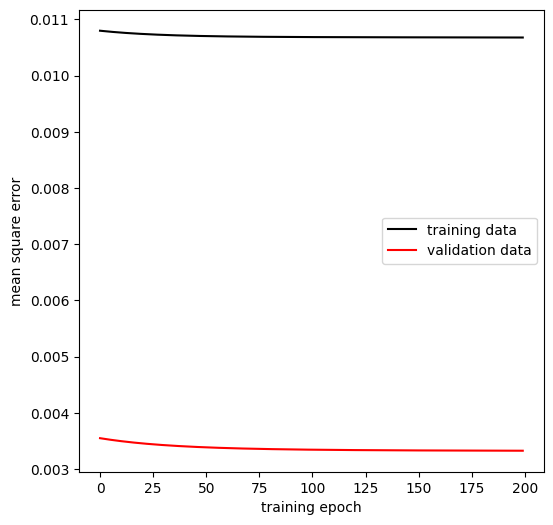

In [123]:
loss_curves = dnn_model_history.history["loss"]
validation_curves = dnn_model_history.history["val_loss"]

curves_fig, curves_ax = plt.subplots(1, figsize = (6, 6))
curves_ax.set_xlabel("training epoch")
curves_ax.set_ylabel("mean square error")
curves_ax.plot(loss_curves, color = "black", label = "training data")
curves_ax.plot(validation_curves, color = "red", label = "validation data")
curves_ax.legend()

plt.show()

### (X): Evaluate Model Against Validation Dataset:

In [124]:
dnn_model.evaluate(
    x_validation,
    y_validation
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0033


0.0033276304602622986

## (X): DNN Predictions:

### (X): Prepare Smooth Input Data:

In [125]:
print(x_training["-t"].min())
print(x_training["-t"].max())

-0.46
-0.02


In [126]:
range_of_t = np.linspace(x_training["-t"].min(), x_training["-t"].max())
range_of_t

array([-0.46      , -0.45102041, -0.44204082, -0.43306122, -0.42408163,
       -0.41510204, -0.40612245, -0.39714286, -0.38816327, -0.37918367,
       -0.37020408, -0.36122449, -0.3522449 , -0.34326531, -0.33428571,
       -0.32530612, -0.31632653, -0.30734694, -0.29836735, -0.28938776,
       -0.28040816, -0.27142857, -0.26244898, -0.25346939, -0.2444898 ,
       -0.2355102 , -0.22653061, -0.21755102, -0.20857143, -0.19959184,
       -0.19061224, -0.18163265, -0.17265306, -0.16367347, -0.15469388,
       -0.14571429, -0.13673469, -0.1277551 , -0.11877551, -0.10979592,
       -0.10081633, -0.09183673, -0.08285714, -0.07387755, -0.06489796,
       -0.05591837, -0.04693878, -0.03795918, -0.02897959, -0.02      ])

In [127]:
range_of_x_b = np.linspace(x_training["x_b"].min(), x_training["x_b"].max())
range_of_x_b

array([0.05      , 0.05387755, 0.0577551 , 0.06163265, 0.0655102 ,
       0.06938776, 0.07326531, 0.07714286, 0.08102041, 0.08489796,
       0.08877551, 0.09265306, 0.09653061, 0.10040816, 0.10428571,
       0.10816327, 0.11204082, 0.11591837, 0.11979592, 0.12367347,
       0.12755102, 0.13142857, 0.13530612, 0.13918367, 0.14306122,
       0.14693878, 0.15081633, 0.15469388, 0.15857143, 0.16244898,
       0.16632653, 0.17020408, 0.17408163, 0.17795918, 0.18183673,
       0.18571429, 0.18959184, 0.19346939, 0.19734694, 0.20122449,
       0.20510204, 0.20897959, 0.21285714, 0.21673469, 0.22061224,
       0.2244898 , 0.22836735, 0.2322449 , 0.23612245, 0.24      ])

### (X): Load all Replicas

In [128]:
replica_paths = sorted(glob.glob("replica_*.keras"))
replicas = [tf.keras.models.load_model(path, compile=False) for path in replica_paths]
print(f"Loaded {len(replicas)} replica models.")

Loaded 3 replica models.


### (X): Run through Original Dataset:

In [145]:
# this is the entire dataset!
x_data = bsa_1_data[["x_b", "-t"]].values.astype(np.float32)

all_predictions = []

for replica in replicas:
    predicted_outputs = replica.predict(x_data)
    all_predictions.append(predicted_outputs)

all_predictions = np.array(all_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [146]:
x_data

array([[ 0.07, -0.02],
       [ 0.09, -0.04],
       [ 0.1 , -0.08],
       [ 0.11, -0.14],
       [ 0.12, -0.26],
       [ 0.12, -0.46],
       [ 0.05, -0.1 ],
       [ 0.07, -0.09],
       [ 0.09, -0.11],
       [ 0.11, -0.12],
       [ 0.16, -0.16],
       [ 0.24, -0.23],
       [ 0.05, -0.08],
       [ 0.07, -0.1 ],
       [ 0.08, -0.11],
       [ 0.1 , -0.13],
       [ 0.13, -0.15],
       [ 0.2 , -0.22]], dtype=float32)

`all_predictions` is a NumPy array of arrays; index corresponds to replica number; each array is $\mathcal{H}$ as a function of $x_{B}$ and $t$. Seems like it just added to the array... `[outputs, inputs]`.

In [130]:
all_predictions

array([[[-0.6206484 ,  0.02856565,  0.07      , -0.02      ],
        [-0.62396365,  0.03530742,  0.09      , -0.04      ],
        [-0.63361514,  0.04431206,  0.1       , -0.08      ],
        [-0.64860266,  0.05708201,  0.11      , -0.14      ],
        [-0.6795507 ,  0.08112997,  0.12      , -0.26      ],
        [-0.73246187,  0.11857648,  0.12      , -0.46      ],
        [-0.64395803,  0.04058866,  0.05      , -0.1       ],
        [-0.63928807,  0.04170084,  0.07      , -0.09      ],
        [-0.6426126 ,  0.04845056,  0.09      , -0.11      ],
        [-0.6432722 ,  0.05332339,  0.11      , -0.12      ],
        [-0.6489096 ,  0.06832576,  0.16      , -0.16      ],
        [-0.65943885,  0.09342104,  0.24      , -0.23      ],
        [-0.6386296 ,  0.03683256,  0.05      , -0.08      ],
        [-0.6419529 ,  0.04357931,  0.07      , -0.1       ],
        [-0.6436153 ,  0.04695408,  0.08      , -0.11      ],
        [-0.6469406 ,  0.05370566,  0.1       , -0.13      ],
        

In [134]:
discrete_bsa_predictions = []

for index, _ in enumerate(all_predictions):
    xb = all_predictions[index][:,2]
    t = all_predictions[index][:,3]
    cff_h_real = all_predictions[index][:,0]
    cff_h_imag = all_predictions[index][:,1]

    fe = compute_fe(t)
    fg = compute_fg(fe)
    f2 = compute_f2(t, fe, fg)
    f1 = compute_f1(fg, f2)
    epsilon = compute_epsilon(xb, _Q_SQUARED)
    y = compute_y(_LAB_K_BEAM, _Q_SQUARED, epsilon)
    m_real_1_1 = compute_m_1_1(t, xb, f1, f2, cff_h_real, 0., 0.)
    m_imag_1_1 = compute_m_1_1(t, xb, f1, f2, cff_h_imag, 0., 0.)
    c_int_1 = compute_c_int_1_(t, _Q_SQUARED, y, m_real_1_1)
    s_int_1 = compute_s_int_1_(t, _Q_SQUARED, y, m_imag_1_1)

    discrete_bsa_predictions.append(s_int_1)

discrete_bsa_predictions = np.array(discrete_bsa_predictions)

In [133]:
discrete_bsa_predictions

array([[ 0.01233742,  0.01740722,  0.02624545,  0.03688123,  0.05380518,
         0.07728184,  0.03926224,  0.03290581,  0.03425284,  0.03315507,
         0.03332248,  0.03359479,  0.03319102,  0.03552283,  0.03606929,
         0.03669684,  0.03552766,  0.03610358],
       [-0.09873888, -0.10883568, -0.12473693, -0.12682298, -0.11241127,
        -0.08347881, -0.20872617, -0.16896372, -0.14580911, -0.12462736,
        -0.08914879, -0.05513962, -0.19817932, -0.17284915, -0.15986799,
        -0.1368162 , -0.10922603, -0.06871486],
       [-0.1053848 , -0.11635592, -0.13361667, -0.13625687, -0.12157652,
        -0.09164371, -0.22311802, -0.18075004, -0.15627313, -0.13378641,
        -0.09619886, -0.06016545, -0.21170273, -0.18497184, -0.17124051,
        -0.14683945, -0.11755811, -0.07464409]], dtype=float32)

In [153]:
mean_bsa = np.mean(discrete_bsa_predictions, axis = 0)
std_dev_bsa = np.std(discrete_bsa_predictions, axis = 0)

In [150]:
mean_bsa

array([-0.06392875, -0.06926146, -0.07736938, -0.07539954, -0.06006087,
       -0.03261356, -0.13086064, -0.10560265, -0.08927646, -0.07508624,
       -0.05067505, -0.02723676, -0.12556368, -0.10743272, -0.0983464 ,
       -0.08231961, -0.06375217, -0.03575179], dtype=float32)

In [154]:
std_dev_bsa

array([0.05399653, 0.06136087, 0.07335638, 0.07948785, 0.08060235,
       0.07777924, 0.12043845, 0.0980584 , 0.08745281, 0.07662944,
       0.05946492, 0.04306331, 0.1123922 , 0.10120592, 0.09515958,
       0.08425676, 0.07028379, 0.05086704], dtype=float32)

In [147]:
bsa_1_data

,bin,k,-t,x_b,q_squared,phi,a_sin_lu_i_1,a_sin_lu_i_1_stat_plus,a_sin_lu_i_1_stat_minus,a_sin_lu_i_1_sys_plus,a_sin_lu_i_1_sys_minus
0,1,NaN,-0.02,0.07,1.71,NaN,-0.225,0.062,0.062,0.010,0.010
1,2,NaN,-0.04,0.09,2.22,NaN,-0.231,0.063,0.063,0.016,0.016
2,3,NaN,-0.08,0.10,2.44,NaN,-0.193,0.069,0.069,0.009,0.009
3,4,NaN,-0.14,0.11,2.72,NaN,-0.249,0.059,0.059,0.013,0.013
4,5,NaN,-0.26,0.12,3.13,NaN,-0.256,0.080,0.080,0.013,0.013
5,6,NaN,-0.46,0.12,3.63,NaN,-0.158,0.115,0.115,0.013,0.013
6,7,NaN,-0.10,0.05,1.34,NaN,-0.248,0.060,0.060,0.067,0.067
7,8,NaN,-0.09,0.07,1.78,NaN,-0.191,0.059,0.059,0.034,0.034
8,9,NaN,-0.11,0.09,2.30,NaN,-0.215,0.069,0.069,0.018,0.018
9,10,NaN,-0.12,0.11,2.92,NaN,-0.248,0.071,0.071,0.032,0.032


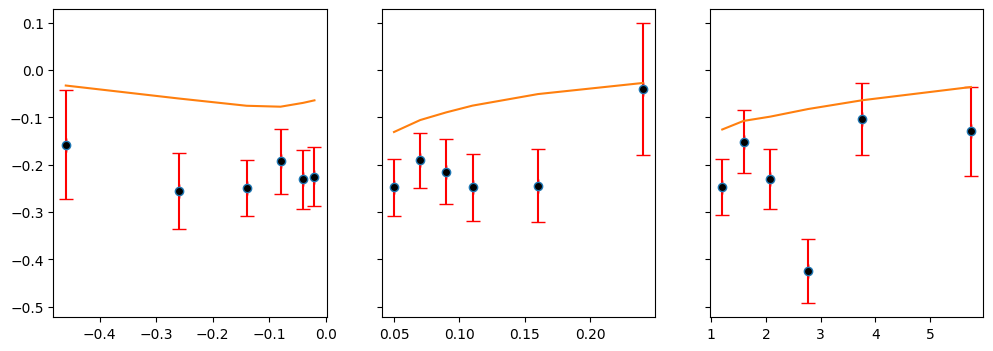

In [157]:
fig2, ax2 = plt.subplots(1, 3, sharey = True, figsize = (12, 4))

ax2[0].errorbar(
    bsa_1_data["-t"].iloc[:6],
    bsa_1_data["a_sin_lu_i_1"].iloc[:6],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[:6],
    marker = 'o',
    markerfacecolor = 'black',
    linestyle = "none",
    ecolor = "red",
    capsize = 5.)

ax2[0].plot(
    bsa_1_data["-t"].iloc[:6],
    mean_bsa[:6])

ax2[1].errorbar(
    bsa_1_data["x_b"].iloc[6:6+6],
    bsa_1_data["a_sin_lu_i_1"].iloc[6:6+6],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[6:6+6],
    marker = 'o',
    markerfacecolor = 'black',
    linestyle = "none",
    ecolor = "red",
    capsize = 5.)

ax2[1].plot(
    bsa_1_data["x_b"].iloc[6:6+6],
    mean_bsa[6:6+6])

ax2[2].errorbar(
    bsa_1_data["q_squared"].iloc[6+6:],
    bsa_1_data["a_sin_lu_i_1"].iloc[6+6:],
    xerr = 0.0,
    yerr = bsa_1_data["a_sin_lu_i_1_stat_plus"].iloc[6+6:],
    marker = 'o',
    markerfacecolor = 'black',
    linestyle = "none",
    ecolor = "red",
    capsize = 5.)

ax2[2].plot(
    bsa_1_data["q_squared"].iloc[6+6:],
    mean_bsa[6+6:])

plt.show()

## (X): Minuit Fitting

In [ ]:
def gpd_h_imag_cross_over(
        x,
        xi,
        t,
        n_val,
        r_val,
        b_val,
        m_val_sq,
        p_val,
        n_sea,
        r_sea,
        b_sea,
        m_sea_sq,
        p_sea):

    cff_h_imaginary = (np.pi*(
        (2.*(4./9.) + 1./9.)*((n_val*r_val/(1. + x))*(2.*x/(1.+x))**(-1*(0.43 + 0.85*t))*(((1.-x)/(1.+x))**b_val)*(1./(1.-((1.-x)/(1.+x))*t/m_val_sq)**p_val))
        + (2./9.)*((n_sea*r_sea/(1. + x))*(2.*x/(1.+x))**(-1*(1.13 + 0.15*t))*(((1.-x)/(1.+x))**b_sea)*(1./(1.-((1.-x)/(1.+x))*t/m_sea_sq)**p_sea))))
    
    return cff_h_imaginary

In [ ]:
def dispersion_relation(x, t, params):
    def integrand(xp):
        cff_h_imag = gpd_h_imag_cross_over(xp, t, *params)
        return (2*xp / (xp**2 - x**2)) * cff_h_imag / np.pi
    result, _ = quad(integrand, 0, 1, limit = 200)
    return result / np.pi

In [ ]:
def observable_model(x, xi, t, params):
    H_im = gpd_h_imag_cross_over(x, t, *params)
    H_re = dispersion_relation(H_im, x, t, xi)
    return BSA_from_CFFs(H_re, H_im, x, xi, t)


In [ ]:
_PARAM_N_VAL = 1.35
_PARAM_P_VAL = 1,
_PARAM_N_SEA = 1.35
_PARAM_R_SEA = 1.
_PARAM_B_SEA = 2. 
_PARAM_M_SEA_SQ = 0.5 # in GeV^2
_PARAM_P_SEA = 2.

initial_guess_r_val = 1.5 # unitless
initial_guess_b_val = 2.3 # unitless
initial_guess_m_val = 0.75 # in GeV^2

cff_h_minuit = Minuit(
    gpd_h_imag_cross_over,
    n_val = _PARAM_N_VAL,
    r_val = initial_guess_r_val,
    b_val = initial_guess_b_val,
    m_val_sq = initial_guess_m_val,
    p_val = _PARAM_P_VAL,
    n_sea = _PARAM_N_SEA,
    r_sea = _PARAM_R_SEA,
    b_sea = _PARAM_B_SEA,
    m_sea_sq = _PARAM_M_SEA_SQ,
    p_sea = _PARAM_P_SEA)

cff_h_minuit.fixed["n_val"] = True
cff_h_minuit.fixed["r_val"] = False
cff_h_minuit.fixed["b_val"] = False
cff_h_minuit.fixed["m_val_sq"] = False
cff_h_minuit.fixed["p_val"] = True
cff_h_minuit.fixed["n_sea"] = True
cff_h_minuit.fixed["r_sea"] = True
cff_h_minuit.fixed["b_sea"] = True
cff_h_minuit.fixed["m_sea_sq"] = True
cff_h_minuit.fixed["p_sea"] = True

NameError: name 'gpd_h_cross_over' is not defined

In [ ]:
def function_of_t(x, t):
    return (2.*x/(1.+x))**(-1*(0.43 + 0.85*t))

In [ ]:
function_of_t(0.2, -.1)

(-0.7619208747836008-2.344951332951657j)